In [ ]:
#Part - 1     Data Acquisition, Cleaning, and Exploratory Analysis

#Task - 1
#Load the dataset

import pandas as pd
import numpy as np

df = pd.read_csv("stroke_prediction_dataset.csv")

df.columns

#Select only the required columns
df = df[['gender',
         'age',
         'hypertension',
         'heart_disease',
         'ever_married',
         'work_type',
         'Residence_type',
         'avg_glucose_level',
         'bmi',
         'smoking_status',
         'stroke']]

# Display first 5 rows
print(df.head())

# column data types
print(df.dtypes)

# DataFrame shape
print(df.shape)

   gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1  Female  61.0             0              0          Yes  Self-employed   
2    Male  80.0             0              1          Yes        Private   
3  Female  49.0             0              0          Yes        Private   
4  Female  79.0             1              0          Yes  Self-employed   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
1          Rural             202.21   NaN     never smoked       1  
2          Rural             105.92  32.5     never smoked       1  
3          Urban             171.23  34.4           smokes       1  
4          Rural             174.12  24.0     never smoked       1  
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married 

In [ ]:
import numpy as np
#TASK - 2
# Null value analysis

#Compute the count and percentage of missing values in every column

print(df.isnull().sum())
print((df.isnull().sum() / df.shape[0]) * 100)

# check whether any blank spaces in every column
print((df == ' ').sum())

#fill numeric columns with the column median
df["bmi"] = df["bmi"].fillna(df["bmi"].median())




gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64
gender               0.000000
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  3.933464
smoking_status       0.000000
stroke               0.000000
dtype: float64
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [ ]:
#TASK - 3
#Duplicate detection and removal
print((df.duplicated().sum()))

# remove the duplicate rows
df.drop_duplicates()

df.isnull().sum()



0


,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [ ]:
#TASK - 4
#Data type correction

#memory usage before conversion
before = df.memory_usage(deep=True).sum()
print("Memory before conversion:", before, "bytes")



Memory before conversion: 1656573 bytes


In [ ]:
#convert multiple repetitive columns
categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for col in categorical_cols:
    df[col] = df[col].astype("category")

after = df.memory_usage(deep=True).sum()
print("Memory after conversion:", after, "bytes")

#Columns like gender , ever_married , work_type , Residence_type,smoking_status contain only a few repeated values. Storing them as category
#instead of object reduces memory usage and can improve the performance of data processing
#and machine learning algorithms.

Memory after conversion: 272532 bytes


In [ ]:
#TASK - 5
#Descriptive statistics and skewness
print(df.describe())

#compute the skewness for each numeric column
numeric_cols = [
    "age",
    "avg_glucose_level",
    "bmi"
    ]

for col in numeric_cols:
    print(f"{col}: {df[col].skew()}")


#A positive skew means that most values are on the lower side, with only a few higher values.
#A negative skew means that most values are on the higher side, with only a few lower values.
#For skewed data, the mean is affected by the uneven distribution, so it may not represent
#the typical value well. Therefore, the median is usually preferred for filling missing values
#because it is less affected by skewness.

               age  hypertension  heart_disease  avg_glucose_level  \
count  5110.000000   5110.000000    5110.000000        5110.000000   
mean     43.226614      0.097456       0.054012         106.147677   
std      22.612647      0.296607       0.226063          45.283560   
min       0.080000      0.000000       0.000000          55.120000   
25%      25.000000      0.000000       0.000000          77.245000   
50%      45.000000      0.000000       0.000000          91.885000   
75%      61.000000      0.000000       0.000000         114.090000   
max      82.000000      1.000000       1.000000         271.740000   

               bmi       stroke  
count  5110.000000  5110.000000  
mean     28.862035     0.048728  
std       7.699562     0.215320  
min      10.300000     0.000000  
25%      23.800000     0.000000  
50%      28.100000     0.000000  
75%      32.800000     0.000000  
max      97.600000     1.000000  
age: -0.1370593225984694
avg_glucose_level: 1.5722838665030459


In [ ]:
#TASK - 6
#Outlier detection with IQR

numeric_cols = [
    "age",
    "avg_glucose_level",
    "bmi"
    ]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

#Outlier Detection:
#The IQR (Interquartile Range) method was used to detect outliers in the numeric columns.
#The lower and upper bounds were calculated as Q1 − 1.5 × IQR and Q3 + 1.5 × IQR, respectively.
#No rows were found outside these bounds, indicating that no outliers were detected using the IQR method.


age: 0 outliers
avg_glucose_level: 627 outliers
bmi: 126 outliers


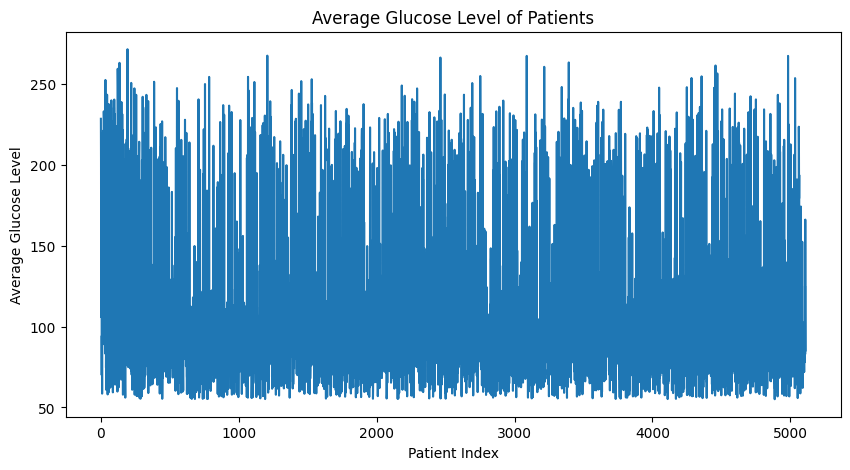

In [ ]:
import matplotlib.pyplot as plt
#TASK - 7
#Visualizations
# A line plot of one numeric variable sorted by time column

plt.figure(figsize=(10,5))
plt.plot(df["avg_glucose_level"])

plt.title("Average Glucose Level of Patients")
plt.xlabel("Patient Index")
plt.ylabel("Average Glucose Level")

# Save the plot
plt.savefig("line_plot_avg_glucose_level.png", dpi=300, bbox_inches="tight")

plt.show()

#Line Plot: A line plot was created using the Average Glucose column.
# The x-axis represents the row index (Patient index), and the y-axis represents the Average glucose level.
# The plot helps visualize how the Average glucose level vary across patients.



/tmp/ipykernel_665/2055399091.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("gender")["avg_glucose_level"].mean().plot(kind="bar")


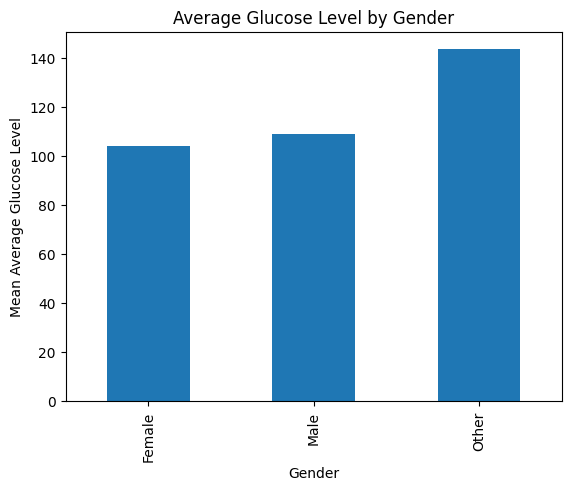

In [ ]:
# A Bar chart

df.groupby("gender")["avg_glucose_level"].mean().plot(kind="bar")

plt.title("Average Glucose Level by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean Average Glucose Level")

# Save the plot
plt.savefig("bar_chart_glucose_by_gender.png", dpi=300, bbox_inches="tight")

plt.show()

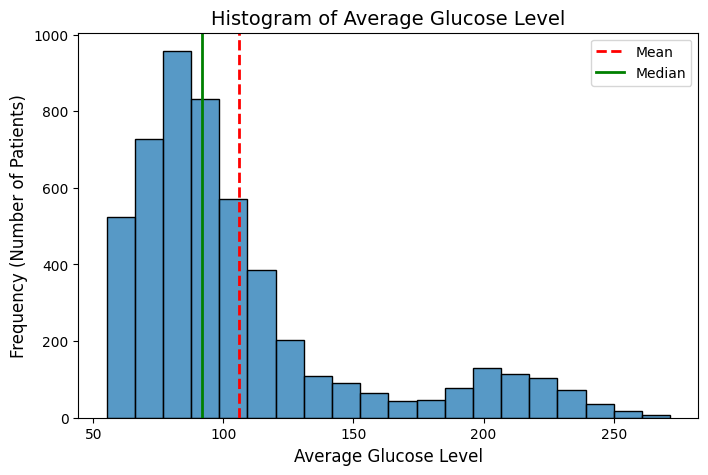

In [ ]:
# A Histogram

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["avg_glucose_level"], bins=20, edgecolor="black")

# Add mean and median lines
plt.axvline(df["avg_glucose_level"].mean(), color="red", linestyle="--", linewidth=2, label="Mean")
plt.axvline(df["avg_glucose_level"].median(), color="green", linestyle="-", linewidth=2, label="Median")

# Title and labels
plt.title("Histogram of Average Glucose Level", fontsize=14)
plt.xlabel("Average Glucose Level", fontsize=12)
plt.ylabel("Frequency (Number of Patients)", fontsize=12)

# Legend
plt.legend()

# Save the figure
plt.savefig("histogram_avg_glucose_level.png", dpi=300, bbox_inches="tight")

plt.show()

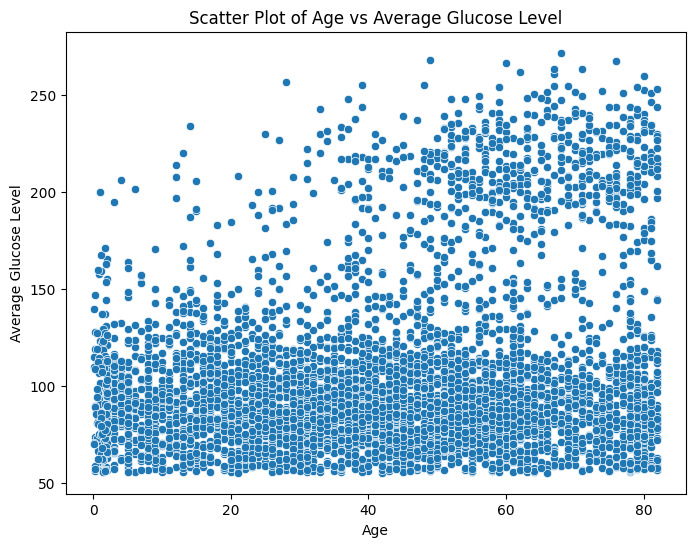

In [ ]:
#Scatter Plot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="age", y="avg_glucose_level")

plt.title("Scatter Plot of Age vs Average Glucose Level")
plt.xlabel("Age")
plt.ylabel("Average Glucose Level")

# Save the figure
plt.savefig("scatter_age_vs_avg_glucose_level.png", dpi=300, bbox_inches="tight")


plt.show()

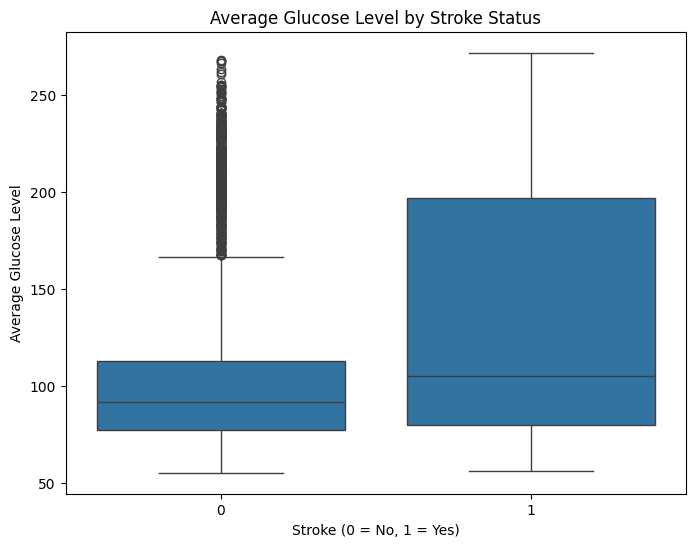

In [ ]:
# A box plot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(x="stroke", y="avg_glucose_level", data=df)

plt.title("Average Glucose Level by Stroke Status")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Average Glucose Level")

# Save the figure
plt.savefig("boxplot_avg_glucose_level_by_stroke.png", dpi=300, bbox_inches="tight")


plt.show()

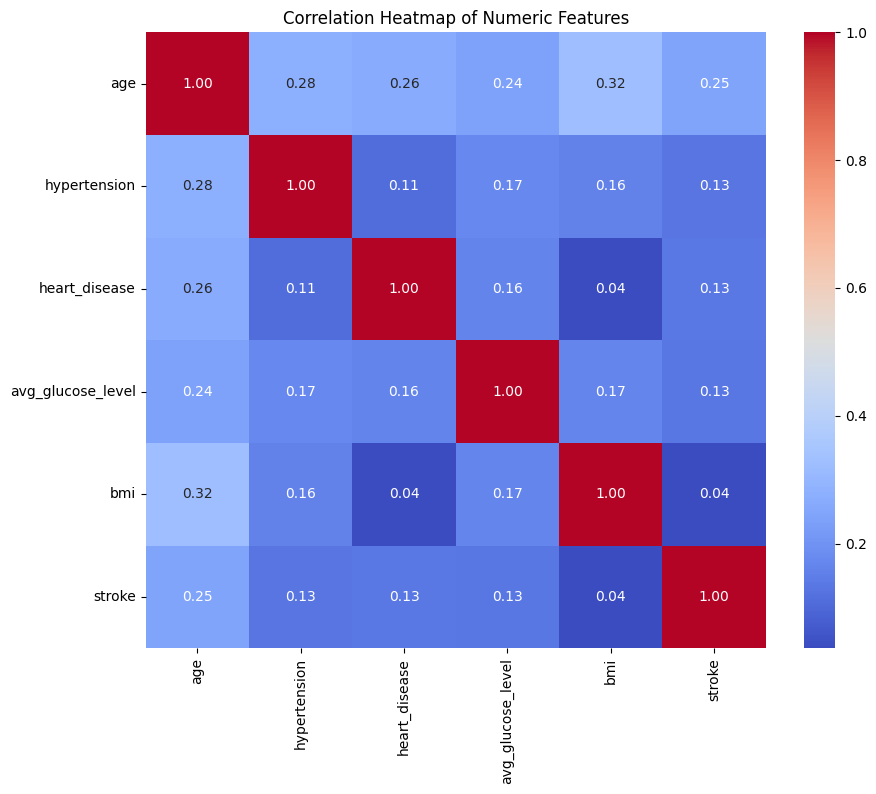

In [ ]:
#TASK - 8

#Correlation heat map

import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Numeric Features")

# Save the figure
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
import numpy as np

# Remove self-correlations
corr = corr_matrix.abs()
np.fill_diagonal(corr.values, 0)

# Find highest absolute correlation
highest_corr = corr.unstack().sort_values(ascending=False)

print(highest_corr.head())

bmi           age              0.324296
age           bmi              0.324296
              hypertension     0.276398
hypertension  age              0.276398
age           heart_disease    0.263796
dtype: float64


In [ ]:
#TASK - 9(a)
 #Imputation strategy comparison

import pandas as pd

#Reload the original dataset
df_original = pd.read_csv("stroke_prediction_dataset.csv")

print("avg_glucose_level")
print("Mean:", df_original["avg_glucose_level"].mean())
print("Median:", df_original["avg_glucose_level"].median())

print("\nbmi")
print("Mean:", df_original["bmi"].mean())
print("Median:", df_original["bmi"].median())

avg_glucose_level
Mean: 106.1476771037182
Median: 91.88499999999999

bmi
Mean: 28.893236911794666
Median: 28.1


In [ ]:
# After that imputation

df_original.fillna({
    "avg_glucose_level": df_original["avg_glucose_level"].median(),
    "bmi": df_original["bmi"].median()
}, inplace=True)

print(df_original[["avg_glucose_level", "bmi"]].isnull().sum())

avg_glucose_level    0
bmi                  0
dtype: int64


In [ ]:
#Task - 9(b)
#Spearman rank correlation

pearson = df.corr(numeric_only=True)

spearman = df.corr(method="spearman", numeric_only=True)

print(pearson)
print(spearman)

                        age  hypertension  heart_disease  avg_glucose_level  \
age                1.000000      0.276398       0.263796           0.238171   
hypertension       0.276398      1.000000       0.108306           0.174474   
heart_disease      0.263796      0.108306       1.000000           0.161857   
avg_glucose_level  0.238171      0.174474       0.161857           1.000000   
bmi                0.324296      0.158293       0.036916           0.166876   
stroke             0.245257      0.127904       0.134914           0.131945   

                        bmi    stroke  
age                0.324296  0.245257  
hypertension       0.158293  0.127904  
heart_disease      0.036916  0.134914  
avg_glucose_level  0.166876  0.131945  
bmi                1.000000  0.036110  
stroke             0.036110  1.000000  
                        age  hypertension  heart_disease  avg_glucose_level  \
age                1.000000      0.280647       0.269627           0.145168   
hyperten

In [ ]:
#Spearman rank correlation differences
import numpy as np

pearson = df.corr(numeric_only=True)
spearman = df.corr(method="spearman", numeric_only=True)

# Absolute difference
diff = (spearman - pearson).abs()

# Remove self-correlations
np.fill_diagonal(diff.values, 0)

# Show the largest differences
print(diff.unstack().sort_values(ascending=False).drop_duplicates().head(10))

age                avg_glucose_level    0.093003
hypertension       avg_glucose_level    0.060433
avg_glucose_level  heart_disease        0.055497
bmi                avg_glucose_level    0.054962
stroke             avg_glucose_level    0.049405
bmi                age                  0.038563
heart_disease      bmi                  0.025770
stroke             bmi                  0.014760
age                heart_disease        0.005831
                   stroke               0.004274
dtype: float64


Top 3 largest differences

1.age ↔ avg_glucose_level → 0.0930
Pearson = 0.238
Spearman = 0.145
Result = ( Pearson > Spearman) - It is linear

2.hypertension ↔ avg_glucose_level → 0.0604
Pearson = 0.174
Spearman = 0.114
Result =( Pearson > Spearman) - Approximately linear but weak relationship

3.heart_disease ↔ avg_glucose_level → 0.0555
Pearson = 0.162
Spearman = 0.106
Result =( Pearson > Spearman) - It is linear although the association is weak


In [ ]:
#TASK - 9(c)
#Grouped aggregation
# take any one numerical column and categorical column to aggregate

result = df.groupby("work_type")["avg_glucose_level"].agg(["mean","std","count"])
print(result)


                     mean        std  count
work_type                                  
Govt_job       107.779772  47.697200    657
Never_worked    96.042727  28.697132     22
Private        106.796844  45.886102   2925
Self-employed  112.645446  51.719490    819
children        94.400277  26.658955    687


/tmp/ipykernel_665/3327258551.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby("work_type")["avg_glucose_level"].agg(["mean","std","count"])


In [ ]:
#Save the clean dataset

df.to_csv("stroke_cleaned_data.csv", index=False)
print("Data is saved sucessfully")

Data is saved sucessfully
